In [71]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from math import sqrt

plt.style.use('ggplot')

In [57]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [58]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nInformation")
df.info()

print("\nSummary")
display(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   o

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000



Missing Values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0


In [59]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

encoder = LabelEncoder()

for col in ["Region", "Model", "Source_Type"]:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01


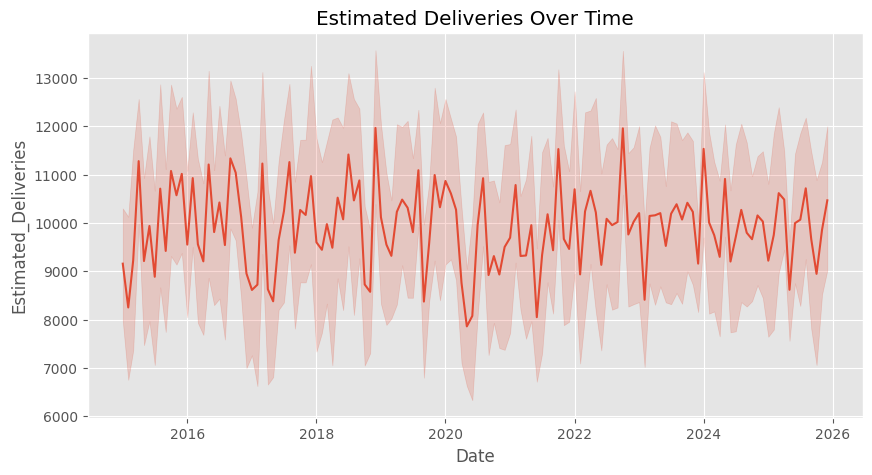

In [60]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x="Date",y="Estimated_Deliveries")
plt.title("Estimated Deliveries Over Time")
plt.show()

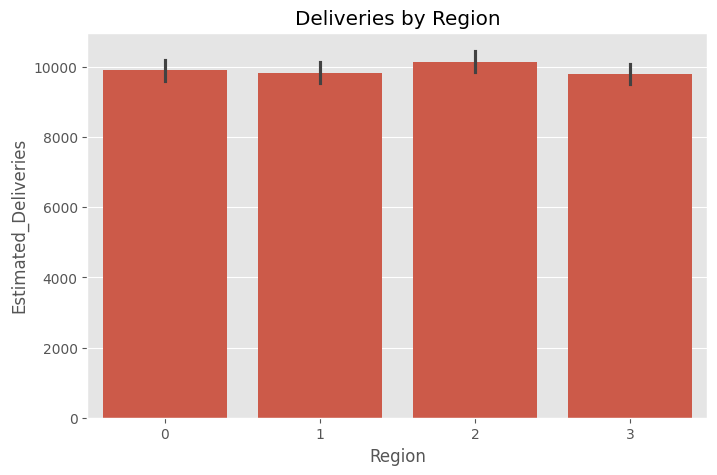

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Region",y="Estimated_Deliveries")
plt.title("Deliveries by Region")
plt.show()

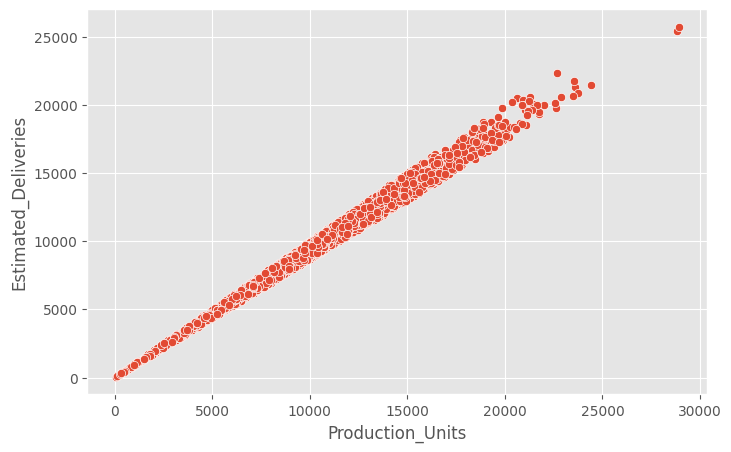

In [62]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)
plt.show()

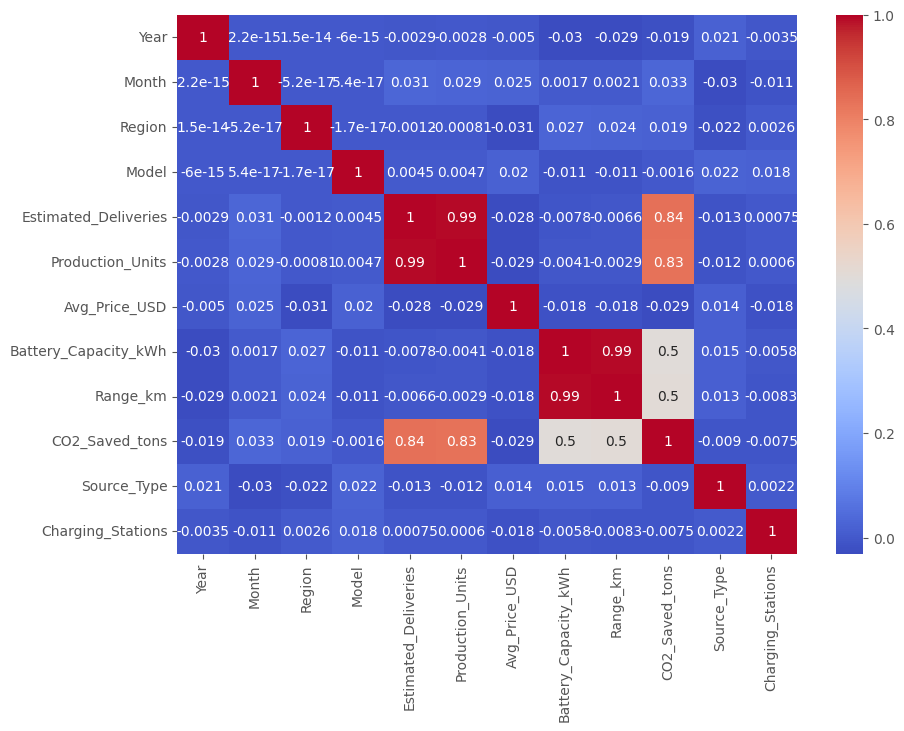

In [63]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [64]:
X = df.drop(
    columns=[
        "Estimated_Deliveries",
        "Date"
    ]
)

y = df["Estimated_Deliveries"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)

(2112, 11)


In [65]:
model = RandomForestRegressor(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [66]:
params = {
    "n_estimators":[100,200],
    "max_depth":[10,20,None]
}

grid = GridSearchCV(
    model,
    params,
    cv=3,
    scoring="r2"
)

grid.fit(
    X_train,
    y_train)

best_model = grid.best_estimator_

print(grid.best_params_)

{'max_depth': 20, 'n_estimators': 100}


In [67]:
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test,pred)

rmse = sqrt(mean_squared_error(y_test,pred))

r2 = r2_score(y_test,pred)

print("MAE :",mae)

print("RMSE :",rmse)

print("R2 Score :",r2)

MAE : 323.01472796416544
RMSE : 409.2673924911152
R2 Score : 0.9887631449860143


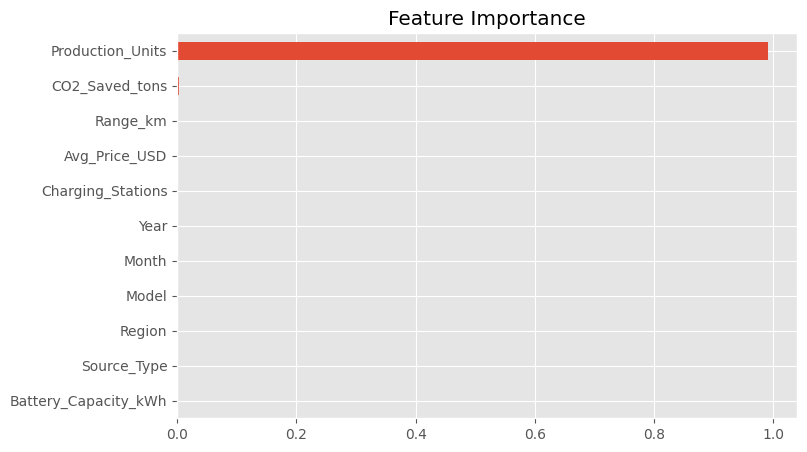

In [68]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

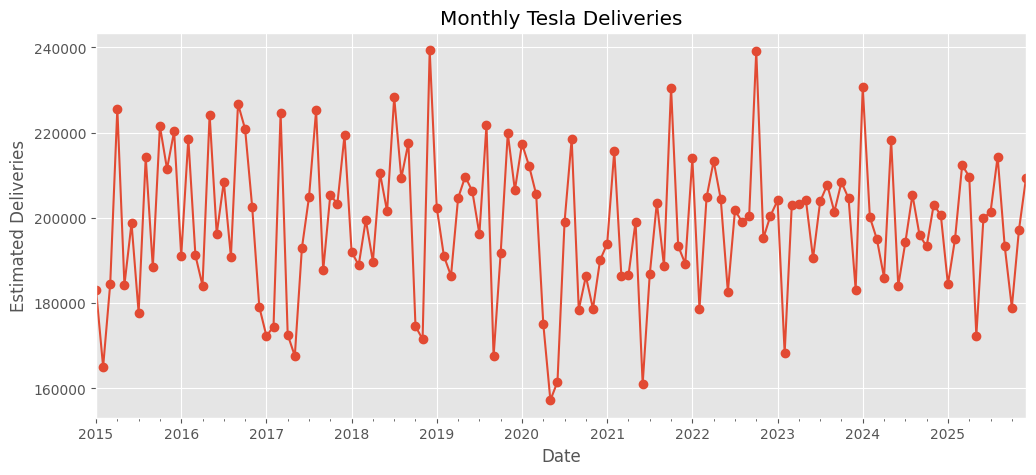

In [69]:
monthly = df.groupby("Date")["Estimated_Deliveries"].sum()

monthly.plot(
    figsize=(12,5),
    marker="o"
)

plt.title("Monthly Tesla Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

In [70]:
##Conclusion
#• The dataset contains 2,640 records with no missing values.
#• Production units have a strong relationship with estimated deliveries.
#• The Random Forest model achieved good prediction performance.
#• Hyperparameter tuning helped improve the model.
#• The monthly delivery trend shows fluctuations over different years.
#• This project demonstrates data preprocessing, EDA, regression modeling and basic time-series analysis.